Initialize the SBI task


In [1]:
# !pip install git+"https://github.com/nidropakshin2/Sequential-FMPE.git#egg=sfmpe&subdirectory=code"
# !pip3 install torch torchvision --index-url https://download.pytorch.org/whl/cu126

In [2]:
config = {
    "prior":
        {
        "gamma_range": [0.05, 0.5],
        "beta_range": [0.5, 5.0],
        },
    "simulator":
        {
        "S": [1500, 2000], # int, tuple, number of Susceptible individuals or bounds for following uniform distribution
        "I": [150, 200], # int, tuple, number of Infectious individuals or bounds for following uniform distribution
        "R": [0, 50], # int, tuple, number of Recovered individuals or bounds for following uniform distribution
        "T": [100, 120],  # int, tuple, simulation duration in days or bounds for following uniform distribution
        },
    "summary": 
        {
        "type": "handmade",
        "input_dim": 3,
        "hidden_dim": 32,
        "num_layers": 2,
        "output_dim": 5,
        "dropout": 0.1,
        },
    "logger":
        {
        "name": "SIR",
        "level": "DEBUG",
        "log_file_path": "logs/sir.log",
        }
}
import os

if not os.path.exists("./logs"):
    os.mkdir("./logs")
if not os.path.exists("./models"):
    os.mkdir("./models")

In [3]:
import yaml
import torch
import time
import matplotlib.pyplot as plt


from sfmpe.tasks.SIR import SIRTask


# config_path = './configs/sir_config.yaml'
# with open(config_path) as f:
#     config = yaml.safe_load(f)
device = 'cpu'
task = SIRTask(config, device)
task.summary.to(device)
logger = task.logger
logger.info("Starting SIR task")

2026-09-12 15:51:52,294 - SIR - INFO - Starting SIR task


In [4]:
import torch

a = torch.tensor([0.1, 1.3, 2.4])
b = torch.tensor([0.05, 0.3, 0.5])

theta_0 = torch.cartesian_prod(a, b)

print(theta_0)
print(theta_0.shape)

tensor([[0.1000, 0.0500],
        [0.1000, 0.3000],
        [0.1000, 0.5000],
        [1.3000, 0.0500],
        [1.3000, 0.3000],
        [1.3000, 0.5000],
        [2.4000, 0.0500],
        [2.4000, 0.3000],
        [2.4000, 0.5000]])
torch.Size([9, 2])


In [5]:
from sfmpe.inference.fm_estimator import FlowMatchingEstimator
from sfmpe.flow.flow_model import FlowModel
from sfmpe.flow.velocity import SimpleVelocityField
from sfmpe.flow.path import AffinePath
from sfmpe.core.distributions import Uniform, Normal


init_dist = Normal(dim=task.theta_dim)
velocity_model = SimpleVelocityField(task.theta_dim, task.data_dim)
path = AffinePath()
flow_model = FlowModel(velocity_model, init_dist, path)
logger.info("Initialized flow model")

# optimizer = torch.optim.Adam(flow_model.velocity_model.parameters(), lr=1e-4)
optimizer = torch.optim.Adam([
                        # {"params": task.summary.parameters(), "lr":1e-4},
                        {"params": flow_model.parameters(), "lr":1e-4}
                        ])
loss_fn = torch.nn.MSELoss()

def preprocessor(theta, x):
    s = task.simulate(theta).to(device)
    x = task.summarize(s).to(device)
    return theta, x

flow_model.to(device)
fm_estimator = FlowMatchingEstimator(flow_model, optimizer, loss_fn)#, dataset_prepocessor=preprocessor)
logger.info("Initialized flow matching estimator")

2026-09-12 15:51:58,674 - SIR - INFO - Initialized flow model
2026-09-12 15:52:01,037 - SIR - INFO - Initialized flow matching estimator


In [6]:
a = torch.tensor([[[1.6667, 0.4016]],
                  [[0.6667, 1.4016]]])
a.unsqueeze(0).expand(4, *a.shape).flatten(0, 1).shape

torch.Size([8, 1, 2])

In [ ]:
from sfmpe.inference.sequential.round_manager import RoundManager
from sfmpe.inference.sequential.proposal import Proposal, ProposalParams

# theta_0, x_0 = task.simulate_dataset((3,))
# theta_0 = torch.tensor([[1.3, 0.3]]).to(device)
# theta_0 = torch.tensor([[0.025, 0.05],
#                            [0.25, 0.5],
#                            [2.5, 0.5],
#                            [1.25, 0.5],
#                            [0.25, 0.05],
#                            [0.125, 0.05],
#                            [0.125, 0.25],
#                            [1.25, 0.25],
#                            [0.625, 0.25]
#                            ]) 
theta_0 = torch.tensor([[1.2621, 0.4558]]).to(device) 
x_0 = task.summarize(task.simulate(theta_0))
# theta_0, x_0 = theta_0.expand(5, -1), x_0.expand(5, -1)
task.logger.info(f"Starting SFMPE for theta {theta_0}")

params = ProposalParams()
params.task = task
params.method = "Truncated"
params.theta_0 = theta_0
params.x_0 = x_0
params.method_params = {'scale': 0.8, 'quantile': 0.1}


2026-09-12 15:52:03,774 - SIR - INFO - Starting SFMPE for theta tensor([[0.0250, 0.0500],
        [0.2500, 0.5000],
        [2.5000, 0.5000],
        [1.2500, 0.5000],
        [0.2500, 0.0500],
        [0.1250, 0.0500],
        [0.1250, 0.2500],
        [1.2500, 0.2500],
        [0.6250, 0.2500]])


In [8]:
# theta = task.prior.sample((1,)).to(device)
# s = task.summarize(task.simulate(theta.expand(1000, *theta.shape)))
# print(theta)
# s.max(dim=0)[0], s.mean(dim=0), s.min(dim=0)[0], s.std(dim=0)

In [9]:
# from sbi.inference import SMCABC

# smc = SMCABC(simulator=lambda theta: task.summary(task.simulator.simulate(theta)),
#              prior=task.prior)
# output = smc(x_0, 
#     num_particles=1000,
#     num_initial_pop=5000,
#     num_simulations=5000,
#     epsilon_decay=0.1)
# plt.scatter(torch.log(output[:, 0]), torch.log(output[:, 1]), s=1)
# plt.scatter(torch.log(theta_0[:, 0]), torch.log(theta_0[:, 1]))

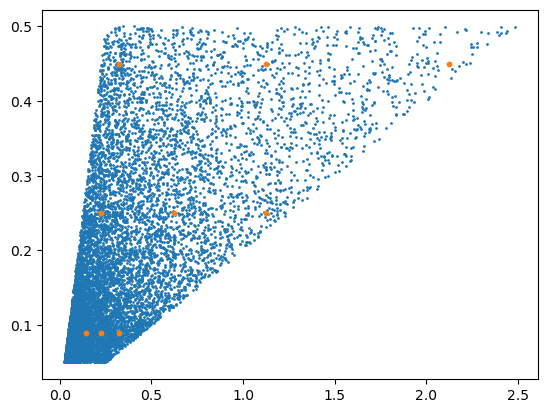

In [10]:
x = task.sample_prior((10000,))

# a = torch.tensor([0.1, 1.3, 2.4])
# b = torch.tensor([0.05, 0.3, 0.5])

# theta_grid = torch.cartesian_prod(a, b)

theta_grid = torch.tensor([[0.025, 0.05],
                           [0.25, 0.5],
                           [2.5, 0.5],
                           [1.25, 0.5],
                           [0.25, 0.05],
                           [0.125, 0.05],
                           [0.125, 0.25],
                           [1.25, 0.25],
                           [0.625, 0.25]
                           ]) 
theta_grid = 0.8 * (theta_grid - torch.tensor([0.625, 0.25])) + torch.tensor([0.625, 0.25])
plt.scatter(x[:, 0], x[:, 1], s=1)
plt.scatter(theta_grid[:, 0], theta_grid[:, 1], s=10)

In [11]:
datetime = time.strftime("%Y-%m-%d_%H_%M_%S")
path = f"./models/SIR_{datetime}.pth.tar.gz"

num_rounds = 3
sims_per_round = 1000
sims_per_sample = 1
epochs = 1000
show_every = epochs // 10 

train = True

manager = RoundManager(task, fm_estimator, params,
                       device=device,
                    #    storage_dir=f"./datasets/SIR_{datetime}"
                       )

if train:
   manager.run_sequential(num_rounds=num_rounds,
                        sims_per_round=sims_per_round,
                        sims_per_sample=sims_per_sample,
                        path=path, epochs=epochs, 
                        show_every=show_every,
                        clean_sampling=True, device=device,
                        batch_size=1000, shuffle=True,)
   loss = manager.losses
   _, ax = plt.subplots()
   ax.plot(loss)
else:
   manager.load_model("./models/SIR_2026-09-04_10_09_55.pth.zip")

2026-09-12 15:52:04,303 - SIR - DEBUG - tensor([[ 0.2461, -0.9575, -1.3617,  0.0351, -0.5953],
        [ 0.2258, -0.9122, -1.3516, -0.0018, -0.5715],
        [ 1.2081, -1.0992, -1.1958, -1.3629,  1.1493],
        [ 0.6507, -0.7821, -1.0825, -1.2705,  1.1223],
        [ 1.0449, -1.3348, -1.0941, -1.4940,  1.5109],
        [ 0.3478, -1.1343, -0.9146, -1.2888,  1.3388],
        [ 0.2368, -0.9485, -1.3754,  0.0694, -0.6705],
        [ 1.0707, -1.0487, -1.1568, -1.3767,  1.2081],
        [ 0.5761, -0.7846, -1.0675, -1.2554,  1.1299]]), tensor([[ 0.2398, -0.9746, -1.3820,  0.0966, -0.6875],
        [ 0.2138, -0.9033, -1.3479, -0.0044, -0.5657],
        [ 1.2983, -1.1538, -1.2155, -1.3730,  1.1471],
        [ 0.6769, -0.7936, -1.0862, -1.2804,  1.1311],
        [ 1.0976, -1.3590, -1.1058, -1.4986,  1.5095],
        [ 0.4301, -1.1399, -0.9177, -1.3448,  1.4130],
        [ 0.2270, -0.9468, -1.3768,  0.0826, -0.6872],
        [ 1.1876, -1.1228, -1.1846, -1.3825,  1.1962],
        [ 0.5397, -0.78

KeyboardInterrupt: 

In [ ]:
data = torch.randn(10, 9, 2)
mask = torch.randint(0, 2, (10, 9), dtype=torch.bool)
data[~mask] = -torch.inf
data

tensor([[[   -inf,    -inf],
         [   -inf,    -inf],
         [   -inf,    -inf],
         [   -inf,    -inf],
         [   -inf,    -inf],
         [ 0.9353,  2.5060],
         [   -inf,    -inf],
         [-0.3063, -1.2302],
         [ 0.3983, -0.0635]],

        [[   -inf,    -inf],
         [   -inf,    -inf],
         [   -inf,    -inf],
         [ 0.9625, -0.1867],
         [ 0.3927, -0.7716],
         [   -inf,    -inf],
         [   -inf,    -inf],
         [   -inf,    -inf],
         [ 0.3965,  0.1273]],

        [[   -inf,    -inf],
         [-0.9135, -0.1747],
         [-0.7213, -2.5002],
         [ 0.5073,  0.8166],
         [   -inf,    -inf],
         [   -inf,    -inf],
         [ 0.1699, -1.8395],
         [-0.0683,  0.5622],
         [ 0.0650, -0.8322]],

        [[ 0.1055,  0.7596],
         [   -inf,    -inf],
         [   -inf,    -inf],
         [   -inf,    -inf],
         [   -inf,    -inf],
         [   -inf,    -inf],
         [   -inf,    -inf],
        

In [ ]:
def clean_sample_experimental(self, shape, **kwargs):
        if not kwargs.get("clean_sampling", False):
            self.logger.debug("NO clean sampling")
            return self.proposal.sample(shape, device=self.device)

        self.sample_shape = self.task.theta_dim

        self.buffer = torch.zeros(*shape, 1, self.sample_shape, device=self.device)
        self.remaining = torch.ones(*shape, 1, dtype=torch.bool, device=self.device)

        print(f"self.buffer {self.buffer, self.buffer.shape}, self.remaining {self.remaining, self.remaining.shape}")
        
        def _merge_samples(new_samples, valid_mask):
            fill_mask = self.remaining & valid_mask
            
            self.buffer[fill_mask] = new_samples[fill_mask]

            new_remaining = self.remaining & ~valid_mask

            print(f"self.buffer {self.buffer, self.buffer.shape}, new_remaining {new_remaining, new_remaining.shape}")
            return new_remaining

        def _mask(data: torch.Tensor) -> torch.Tensor | None:
            if data.numel() == 0:
                return None
            
            if self.task.check_support is None:
                mask1 = torch.ones_like(data, dtype=torch.bool)
                mask1 = mask1.all(dim=-1)
            else:
                mask1 = self.task.check_support(data)
            print("mask1", mask1)
            if self.proposal_params.method == 'Truncated':
                try:
                    logp = self.proposal.log_prob(data[mask1].to(self.device))
                    mask2 = (logp >= torch.quantile(logp, self.proposal_params.method_params.get('quantile', None)))
                    mask = mask1.clone()
                    mask[mask1] = mask2
                
                except NotImplementedError:
                    pass
            return mask1
        
        while self.remaining.any():

            samples = self.proposal.sample(shape, device=self.device)

            print("samples shape", samples.shape)
            valid_mask = _mask(samples)   
            print(f"valid mask, {valid_mask, valid_mask.shape}")             
            # accepted = valid_mask & self.remaining
            
            self.remaining = _merge_samples(samples, valid_mask)
            print(f"remaining {self.remaining, self.remaining.shape}")

        return self.buffer

# theta = clean_sample_experimental(manager, (10, ), clean_sampling=True)

In [12]:
sim_store = manager.store
# log_plot = False

# _, ax = plt.subplots(num_rounds, 1, sharex=True, figsize=(3, 3 * num_rounds))
# for r in range(num_rounds):
#     theta, x = sim_store.theta[r], sim_store.x[r]
#     if log_plot:
#         ax[r].scatter(torch.log(theta[:, :, 0]), torch.log(theta[:, :, 1]), s=1/(r+1), alpha=(r+1) / 10)
#         ax[r].scatter(torch.log(theta_0[:, 0]), torch.log(theta_0[:, 1]), s=10, color="black")
#         ax[r].set_xlim((-4, 2))
#         ax[r].set_ylim((-3.1, -0.5))
#     else:
#         ax[r].scatter(theta[:, :, 0], theta[:, :, 1], s=1/(r+1), alpha=(r+1) / 10)
#         ax[r].scatter(theta_0[:, 0], theta_0[:, 1], s=10, color="black")
#         ax[r].set_xlim(0, 2.5)
#         ax[r].set_ylim(0, 0.5)

In [ ]:
# posterior = manager.build_posterior()
# theta_pred = posterior.sample(size=(1000,))
# # i = 1
# if log_plot:
#     plt.scatter(torch.log(theta_pred[:, :, 0]), torch.log(theta_pred[:, :, 1]), s=1)
#     plt.scatter(torch.log(theta_0[:, 0]), torch.log(theta_0[:, 1]), s=10, color="black")
#     plt.xlim((-4, 1))
#     plt.ylim((-3, -1))
# else:
#     plt.scatter(theta_pred[:, :, 0], theta_pred[:, :, 1], s=1)
#     plt.scatter(theta_0[:, 0], theta_0[:, 1], s=10, color="black")
#     plt.xlim(0, 2.5)
#     plt.ylim(0, 0.5)

# theta_0, theta_pred.mean(dim=0), theta_pred.std(dim=0) 

2026-09-12 16:30:08,521 - SIR - DEBUG - tensor([[ 0.2479, -0.9602, -1.3713,  0.0418, -0.6149],
        [ 0.2333, -0.9253, -1.3602,  0.0217, -0.6065],
        [ 1.2378, -1.1107, -1.2021, -1.3676,  1.1491],
        [ 0.7049, -0.8083, -1.0953, -1.2743,  1.1162],
        [ 0.9949, -1.2606, -1.0919, -1.4803,  1.4810],
        [ 0.3686, -1.1578, -0.9135, -1.3642,  1.4286],
        [ 0.2260, -0.8980, -1.3389, -0.0480, -0.5038],
        [ 1.1103, -1.0662, -1.1680, -1.3742,  1.1962],
        [ 0.5743, -0.7667, -1.0651, -1.2637,  1.1380]]), tensor([[ 0.2313, -0.9680, -1.3802,  0.0980, -0.6897],
        [ 0.2134, -0.9231, -1.3634,  0.0496, -0.6413],
        [ 1.2165, -1.1051, -1.1957, -1.3708,  1.1603],
        [ 0.6838, -0.8017, -1.0860, -1.2863,  1.1394],
        [ 1.0398, -1.3319, -1.0952, -1.5004,  1.5253],
        [ 0.4595, -1.1546, -0.9315, -1.3149,  1.3673],
        [ 0.2129, -0.9194, -1.3590,  0.0330, -0.6148],
        [ 1.1227, -1.0886, -1.1696, -1.3777,  1.2027],
        [ 0.5361, -0.76

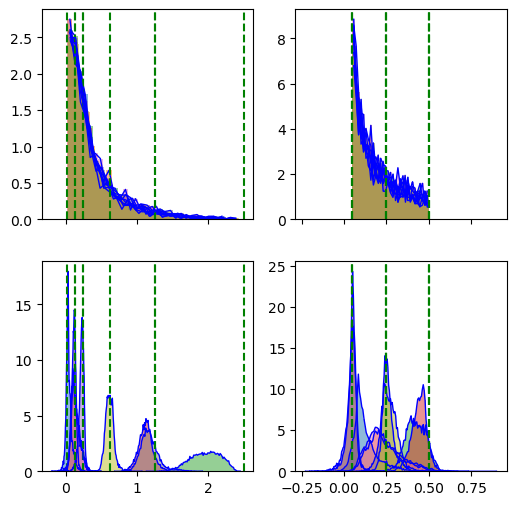

In [14]:
from sfmpe.utils.plotting import dist_plot

sim_store = manager.store
posterior = manager.build_posterior()

dist_plot(
                sim_store.theta[0], 
                # sim_store.theta[1],
                # sim_store.theta[2],  
                posterior.sample((10000,)),
                # manager.clean_sample((1000, )),
                true_param=theta_0)

tensor([[0.0250, 0.0500],
        [0.2500, 0.5000],
        [2.5000, 0.5000],
        [1.2500, 0.5000],
        [0.2500, 0.0500],
        [0.1250, 0.0500],
        [0.1250, 0.2500],
        [1.2500, 0.2500],
        [0.6250, 0.2500]]) tensor([[0.0444, 0.1237],
        [0.1435, 0.2422],
        [1.9655, 0.4235],
        [1.1201, 0.4438],
        [0.2235, 0.0418],
        [0.1131, 0.0451],
        [0.1340, 0.2252],
        [1.1793, 0.2521],
        [0.6181, 0.2734]]) tensor([[0.0412, 0.0719],
        [0.0593, 0.0981],
        [0.2084, 0.0599],
        [0.1000, 0.0452],
        [0.0359, 0.0332],
        [0.0358, 0.0284],
        [0.0567, 0.0944],
        [0.1328, 0.0395],
        [0.0610, 0.0443]])


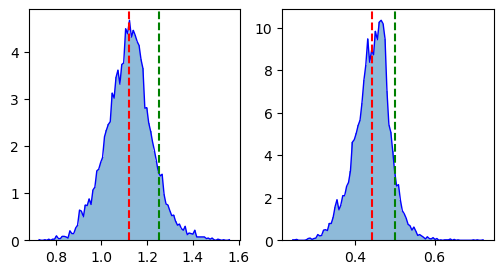

In [15]:
K = 3
pred = posterior.sample((10000,))
print(theta_0, pred.mean(dim=0), pred.std(dim=0))

def dist_plot2(*dists, true_param=None, pred_param=None):
    # assert len(dist1.shape) == len(dist2.shape) and dist1.shape[-1] == dist2.shape[-1]
    theta_dim = dists[0].shape[-1]
    K = dists[0].shape[-2]
    num_bins  = [int(dists[i].shape[0] ** 0.5) for i in range(len(dists))]
    
    _, ax = plt.subplots(len(dists), theta_dim, sharex='col', figsize=(3*theta_dim, 3*len(dists)))
    if len(dists) == 1:
        ax = [ax]
    for j in range(theta_dim):
        for thetas, i in zip(dists, range(len(dists))):
            for k in range(K):
                counts, bins, patches = ax[i][j].hist(thetas[:, k, j], bins=num_bins[i], alpha=0.5, density=True)

                bin_centers = (bins[:-1] + bins[1:]) / 2

                ax[i][j].plot(bin_centers, counts, 'b-', linewidth=1)

                if true_param is not None:
                    ax[i][j].axvline(x=true_param[k, j], linestyle='--', color='green')
                
                if pred_param is not None:
                    ax[i][j].axvline(x=pred_param[k, j], linestyle='--', color='red')

dist_plot2(pred[:, K, :].unsqueeze(1), true_param=theta_0[K].unsqueeze(0), pred_param=pred.mean(dim=0)[K].unsqueeze(0))

In [ ]:
def clean_sample(shape, **kwargs):
    print(kwargs.get("clean_sampling", False))
    
clean_sample((10, ))

False


In [ ]:
# tensor([[0.2387, 0.0550],
#         [1.2621, 0.4558],
#         [0.0839, 0.0572],
#         [0.0906, 0.0638],
#         [0.1031, 0.0583],
#         [0.4003, 0.2856],
#         [1.1808, 0.3677],
#         [0.2910, 0.1566],
#         [1.1429, 0.4723],
#         [0.7993, 0.4970]]) tensor([[0.2946, 0.0723],
#         [1.4920, 0.5129],
#         [0.1195, 0.0786],
#         [0.1079, 0.1005],
#         [0.1444, 0.0744],
#         [0.4904, 0.3817],
#         [1.4859, 0.4770],
#         [0.4050, 0.2104],
#         [1.3361, 0.5179],
#         [0.8700, 0.5225]]) tensor([[0.0102, 0.0170],
#         [0.0403, 0.0173],
#         [0.0121, 0.0086],
#         [0.0062, 0.0044],
#         [0.0095, 0.0054],
#         [0.0276, 0.0190],
#         [0.0399, 0.0176],
#         [0.0147, 0.0100],
#         [0.0594, 0.0146],
#         [0.0238, 0.0194]])

IndexError: index 1 is out of bounds for dimension 1 with size 1

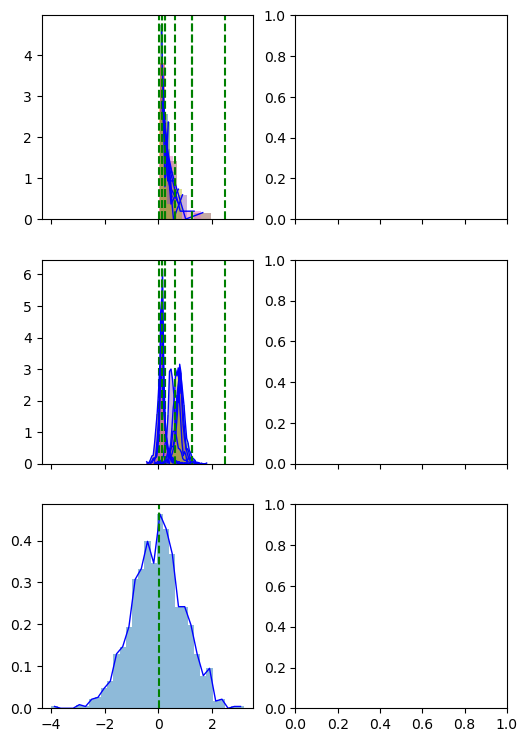

In [ ]:
flow_model.velocity_model.eval()
flow_model.velocity_model.to(x_0.device)

x_0 = params.x_0
x_0_expanded = x_0.unsqueeze(0).expand(1000, *x_0.shape)

theta_pred = flow_model.init_dist.sample((*x_0_expanded.shape[:-1],)).to(x_0_expanded.device)
t = torch.linspace(0, 1, steps=32 + 1).to(x_0_expanded.device)
        
with torch.no_grad():
    for i in range(32):
        theta_pred = flow_model.velocity_model.step(theta=theta_pred, x=x_0_expanded, t_start=t[i], t_end=t[i+1])
theta_pred = theta_pred.detach()
dist_plot(sim_store.theta[0], 
                theta_pred, 
                flow_model.init_dist.sample((1000, 1, )).to(x_0_expanded.device),
                true_param=theta_0)

In [ ]:
# log_probs = posterior.log_prob(theta_pred)

In [ ]:
# plt.scatter(theta_pred[..., 1], log_probs, c=log_probs)

In [ ]:
# exp = torch.exp(log_probs)
# plt.scatter(theta_pred[..., 1], exp, c=exp)
# plt.ylim(0, 10000)

In [ ]:
# samples = flow_model.init_dist.sample((10000,)) 
# logs = flow_model.init_dist.log_prob(samples)
# exp = torch.exp(logs)
# plt.scatter(samples[..., 0], exp, c=exp)

In [ ]:
# log_probs = posterior.log_prob(theta_pred)

# torch.quantile(log_probs, 0.15)
# baselogp, logp_corr = log_probs
# logp_pred = baselogp + logp_corr[-1]

In [ ]:
# mask = torch.where(log_probs <= torch.quantile(log_probs, 0.5))
# plt.scatter(theta_pred[mask][:, 0], theta_pred[mask][:, 1], s=1)
# plt.scatter(theta_0[:, 0], theta_0[:, 1], color="black", s=10)
# plt.xlim(0, 2.5)
# plt.ylim(0, 0.5)

In [ ]:
# from sfmpe.data.round_dataset import RoundDataset
# from sfmpe.data.simulation_store import SimulationStore


# init_dist = Uniform()
# v_model = SimpleVelocityField(task.theta_dim, task.data_dim, hidden_dim=64)
# path = AffinePath()
# flow = FlowModel(v_model, init_dist, path)

# optimizer = torch.optim.Adam(flow.parameters(), lr=1e-4)
# loss_fn = torch.nn.MSELoss()

# def preprocessor(theta, x, *args):
#     std_theta = torch.log(theta).std(dim=-1)
#     std_x     = x.std(dim=-1)
#     alpha_theta = 0.1
#     alpha_x     = 0.1
#     return torch.exp(torch.log(theta) + alpha_theta * std_theta * torch.randn_like(theta)), \
#                x + alpha_x * std_x * torch.randn_like(x)


# fm_estim = FlowMatchingEstimator(flow, optimizer, loss_fn, dataset_prepocessor=preprocessor)


# store = SimulationStore()
# theta, x = task.simulate_dataset((10000, ))
# store.add(theta, x, 0)
# dataset = RoundDataset(store, [0])

In [ ]:
# loss = fm_estim.train(dataset, epochs=2000, show_every=200)
# posterior = fm_estim.build_posterior()
# # plt.scatter(theta_0[:, 0], theta_0[:, 1], s=1)

In [ ]:
# theta, x = dataset.theta, dataset.x
# theta_1, x = preprocessor(theta, x)
# # theta_1 = torch.exp(torch.log(theta) + 0.1*torch.randn_like(theta))
# plt.scatter(torch.log(theta_1[:, 0]), torch.log(theta_1[:, 1]), s=1)

# theta.std(dim=0) * torch.randn_like(theta)

In [ ]:
# import corner

# for i in range(theta_pred.shape[1]):
#     samples = theta_pred[:, i, :].numpy()
#     fig = corner.corner(samples, bins=40, levels=[0.5], labels=['beta', 'gamma'],
#                         plot_datapoints=False, plot_contours=True, smooth=1)

In [ ]:
# def sbc(manager):
#     thetas_prior = manager.task.prior.sample((1000,))
#     num_samples = 1000
#     samples = manager.proposal.sample((num_samples, 1000,))
#     print(samples.shape, thetas_prior[:, None, None, :].shape)
#     ranks = (samples < thetas_prior[:, None, None, :]).sum(dim=-1)
#     print(ranks.shape)
#     return ranks


# ranks = sbc(manager)
# _, ax = plt.subplots(1, 2, figsize=(8, 2.5))
# ax[0].hist(ranks[:, 0].cpu(), bins=20, color="#8000ff")
# ax[1].hist(ranks[:, 1].cpu(), bins=20, color="orange")
